# Fraud Detection — Exploratory Data Analysis

## Objective
The purpose of this project is to build a model that can detect fraudulent activity based on transaction data, and answer the following questions: 

- Q1. Why is `TRANSFER` riskier than `CASH_OUT`, despite being the only two fraud-bearing types?

- Q2. Is there a `TRANSFER` -> `CASH_OUT` behavioral chain — does fraud money move as `TRANSFER` then `CASH_OUT`?

In this notebook, the objective is to explore the structure and distributions in paysim.csv to (1) build an evidence-based hypothesis for why `TRANSFER` carries more fraud risk than `CASH_OUT`, and (2) confirm if there is a behavioral chain between `TRANSFER` and `CASH_OUT`. 

## Inputs
- `..\data\raw\paysim.csv`
- PaySim dataset — 6,362,620 transaction events, 11 columns
- Column Description:
    - `step`: Time is discretized: 1 step = 1 hour
    - `type`: `CASH_IN`, `CASH_OUT`, `DEBIT`, `PAYMENT`, `TRANSFER`
    - `amount`: Transaction amount (`float64`)
    - `nameOrig`: Name of origin Account (`str`)
    - `oldbalanceOrg`: Old account balance at origin (`float64`)
    - `newbalanceOrig`: New account balance at origin (`float64`)
    - `nameDest`: Name of destination account (`str`)
    - `oldbalanceDest`: Old account balance at destination (`float64`)
    - `newbalanceDest`: New account balance at destination (`float64`)
    - `isFraud`(Target): Fraudulent Transaction (`int64`)
    - `isFlaggedFraud`: Transaction flagged as fraudulent (`int64`)

## Outputs
- feature engineering steps
- chain-indicator hypothesis to test in feature engineering

## 1.1 Setup & Imports

Importing necessary libraries and setting plot styling and paths for reprodicability. 

In [2]:
import warnings
warnings.filterwarnings('ignore') # suppress outputs of warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme()
plt.style.use('seaborn-v0_8')
plt.rcParams['figure.figsize'] = (10, 6)

RAW_DATA_PATH = '../data/raw/paysim.csv'
RANDOM_STATE = 42

## 1.2 Load Dataset

Using pandas to read the dataset and verifying the `.csv` has been loaded properly using `.shape` and `.head()`

In [3]:
df = pd.read_csv(RAW_DATA_PATH)
print(df.shape)
df.head()

(6362620, 11)


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


## 1.3 Sanity Checks

Checking for: incorrect data types, missing values, duplicates, any impossible or suspicious values, and unexpected categories. These checks ensure analysis is done without inaccurate or missing data, so that down stream models can be trained and tested on good data

In [4]:
df.dtypes

step                int64
type                  str
amount            float64
nameOrig              str
oldbalanceOrg     float64
newbalanceOrig    float64
nameDest              str
oldbalanceDest    float64
newbalanceDest    float64
isFraud             int64
isFlaggedFraud      int64
dtype: object

All data types look to be correct — continuous features like `amount` and `oldbalanceOrg` are `float64`, binary features are `int64`, and names are `str`. 

In [5]:
df.isnull().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

all sums are 0 therefore no obvious (`null`) missing values. 

Given the dataset was produced from simulated transaction there is a high potential for duplicated rows to exist, so `.duplicated().sum()` will give sums of any duplicate transaction.

In [7]:
df.duplicated().sum()

KeyboardInterrupt: 

np.int64(0) means there were no duplicate rows. 

I run `.describe()` to make sure continuous features are as they should be with no impossible values, and to get a peak at the overall distribution of the features. 

In [ ]:
df.describe()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06
mean,2.433972e+02,1.798619e+05,8.338831e+05,8.551137e+05,1.100702e+06,1.224996e+06,1.290820e-03,2.514687e-06
std,1.423320e+02,6.038582e+05,2.888243e+06,2.924049e+06,3.399180e+06,3.674129e+06,3.590480e-02,1.585775e-03
min,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.560000e+02,1.338957e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2.390000e+02,7.487194e+04,1.420800e+04,0.000000e+00,1.327057e+05,2.146614e+05,0.000000e+00,0.000000e+00
75%,3.350000e+02,2.087215e+05,1.073152e+05,1.442584e+05,9.430367e+05,1.111909e+06,0.000000e+00,0.000000e+00
max,7.430000e+02,9.244552e+07,5.958504e+07,4.958504e+07,3.560159e+08,3.561793e+08,1.000000e+00,1.000000e+00


`step`: large jump from 75% being 3.350000e+02 to max 7.430000e+02, so I expect to see a right-skewed distribution.

`amount`: 50% 7.487194e+04 and 75% 2.087215e+05 and max 9.244552e+07, so with this big jump I expect to see a right-skewed distribution.  

`oldbalanceOrg` and `newbalanceOrig`: Both have large differneces between their 75% and max (`oldbalanceOrg`: 75%=1.073152e+05, max=5.958504e+07 `newbalanceOrig`: 75%=1.442584e+05, max=4.958504e+07 ), so I expect to see a non-normal distribution. Additionally, the 25% 0.00 for `oldbalanceOrg` and 0.00 for 25% and 50% for `newbalanceOrig` is suspicious due to the high number of zeros in accounts. This could be a singal of potential data quality problem, or it could be a legitimate structural feature of this dataset — e.g. certain transactions types drains accounts, or many accounts have low/no-balance.

`oldbalanceDest` and `newbalanceDest`: Like `oldbalanceOrg` and `newbalanceOrig`, both `oldbalanceDest` and `newbalanceDest` have large differences between their 75% and max (`oldbalanceDest`: 75%=9.430367e+05 , max=3.560159e+08 `newbalanceDest`: 75%=1.111909e+06 , max=3.561793e+08), so I again expect to see a non-normal unbalanced distribution. Additioanlly, they also have 25% 0.00 which again could be a signal of a data quality problem or a legitimate structural feature. Lastly, there is a significant difference in the 75%, max, and mean of old and new balance origins and destinations.
|features | 75% | max | mean |
|---|---|---|---|
| oldbalanceOrg | 1.07e+05 | 5.96e+07 | 8.34e+05 |
| newbalanceOrig | 1.44e+05 | 4.96e+07 | 8.55e+05 |
| oldbalanceDest | 9.43e+05 | 3.56e+08 | 1.10e+06 |
| newbalanceDest | 1.11e+06 | 3.56e+08 | 1.22e+06 |

This could be a clue relevant to Q1 (why `Transfer` is riskier). This will be further investigated in bivariate analysis.  

`isFraud` and `isFlaggedFraud`: both these features have majority zeros in all % categories which signals that the target `isFraud` is imbalanced. 

I run `.describe(include='object')` to check if the three categorical features have any unexpected categories.

In [13]:
df.describe(include='object')

,type,nameOrig,nameDest
count,6362620,6362620,6362620
unique,5,6353307,2722362
top,CASH_OUT,C2098525306,C1286084959
freq,2237500,3,113


`type`: Everything appears to be as it should, 5 unique categoires, and `CASH_OUT` being the most common.

`nameOrig`: Majority are unique names with `C2098525306` being the most frequent account appearing 3 times — each account rarely originates more than one transaction. 

`nameDest`: Has far fewer unique names than `nameOrig` with `C1286084959` being the most frequent account appearing 113 times — some accounts receive many transactions. 

The difference in the origin and destination of accounts suggest that accounts in this dataset are primarily used for transfering money? This also makes my behavior chain question (Q2: `TRANSFER` -> `CASH_OUT`) more plausible to find in the actual data, because it shows that many of the accounts are transfering money to the destination accounts and then likely cashing out. 

## 1.4 Research Question Refinement

Initially, my research question was "does fraud differ by transaction type", and to ensure the dataset held the information needed to answer that question, not just train a model for fraud detection, I first ran `.value_counts()` on `isFraud` to see if there was enough fraudulent cases to train on. Then I used pandas function `.groupby()` and other aggregate functions to get the sum, mean, and count of the different transaction types to see the distribution of fraudulent cases among the transaction types.  

In [10]:
print(df['isFraud'].value_counts())
df['isFraud'].value_counts(normalize=True)

isFraud
0    6354407
1       8213
Name: count, dtype: int64


isFraud
0    0.998709
1    0.001291
Name: proportion, dtype: float64

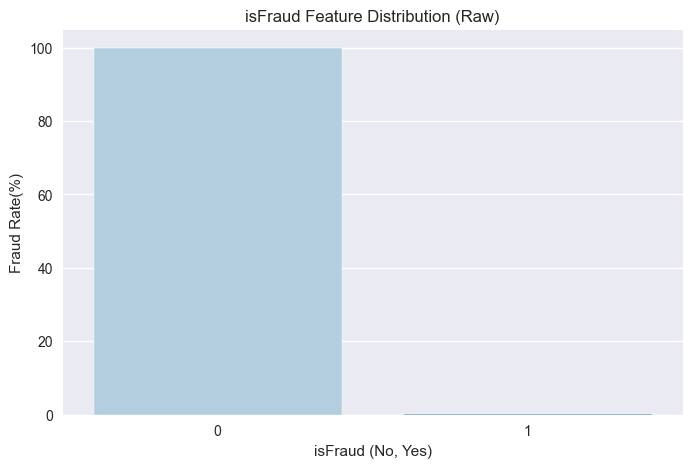

In [5]:
fraud_rates = df['isFraud'].value_counts(normalize=True) # the dataset is too large so this prevents running into memory error

plt.figure(figsize=(8, 5))
sns.barplot(x=fraud_rates.index, y=fraud_rates.values*100, palette='Blues')
plt.title('isFraud Feature Distribution (Raw)')
plt.xlabel('isFraud (No, Yes)')
plt.ylabel('Fraud Rate(%)')
plt.savefig('../images/target_distribution.png', bbox_inches='tight')
plt.show()

The plot visually shows the extreme imbalance between the two classes of the target variable — ~0.13% of transactions are fraudulent, a ~770:1 imbalance. This means that class weights will need to be adjusted, and evaluation will more dependent on recall than on accuracy alone. 


In [4]:
df.groupby('type')['isFraud'].agg(['sum', 'mean', 'count'])

,sum,mean,count
type,,,
CASH_IN,0,0.000000,1399284
CASH_OUT,4116,0.001840,2237500
DEBIT,0,0.000000,41432
PAYMENT,0,0.000000,2151495
TRANSFER,4097,0.007688,532909


Only two of the five `type` categories — `CASH_OUT` and `TRANSFER` — have cases of fraud. Additionally, although `CASH_OUT` has more cases of fraud (4116) than `TRANSFER` (4097), `TRANSFER` has a significantly higher rate of fraud (0.77%) than `CASH_OUT` (0.18%). This finding caused me to change my initial question of "does fraud differ by transaction types?" to: Q1 "Why is `TRANSFER` riskier than `CASH_OUT`, despite being the only two fraud-bearing types?" and Q2 "Is there a `TRANSFER` -> `CASH_OUT` behavioral chain — does fraud money move as `TRANSFER` then `CASH_OUT`?".


## 1.5 Univariate Analysis 

To visualize and analyze the features, looking at distributions and potential outliers, I conduct univariate analysis using a histogram with a KDE overlay for the continuous features (`step`, `amount`, `oldbalanceOrg`, `newbalanceOrig`, `oldbalanceDest`, `newbalanceDest`) and a bar plot of value counts for the categorical features (`type`, `isFlaggedFraud`).

Given the dataset's size (6.3M+ rows), plotting raw rows directly is not feasible (memmory error). For the continuous features, I apply a `log1p` transform (log(x+1), which safely handles the many true-zero values present in the balance columns) before plotting, and compute the histogram on the full dataset while sampling 100k rows for the KDE curve to keep runtime reasonable. 

For categorical features, `type` and `isFlaggedFraud` are plotted as bar plots of their value proportions (%), aggregated with `value_counts(normalize=True)` first to avoid the memory issues of plotting raw rows directly.

`nameOrig` and `nameDest` are excluded from this plot becuase both are high-cardinality (contains many unique/distinct values) identifier columns, and `nameOrig` in particular is near-unique per row, making a distribution plot meaningless. Instead, I inspect their most frequent values directly with `.value_counts().head(10)`, which reflects the asymmetry noted earlier (`nameOrig` rarely repeats, `nameDest` repeats heavily) and will be relevant to the chain analysis in Q2.

`isFraud` is not included here since its distribution was analyzed separately in the question refinement section above.

### Continuous Features
`step`, `amount`, `oldbalanceOrg`, `newbalanceOrig`, `oldbalanceDest`, `newbalanceDest`

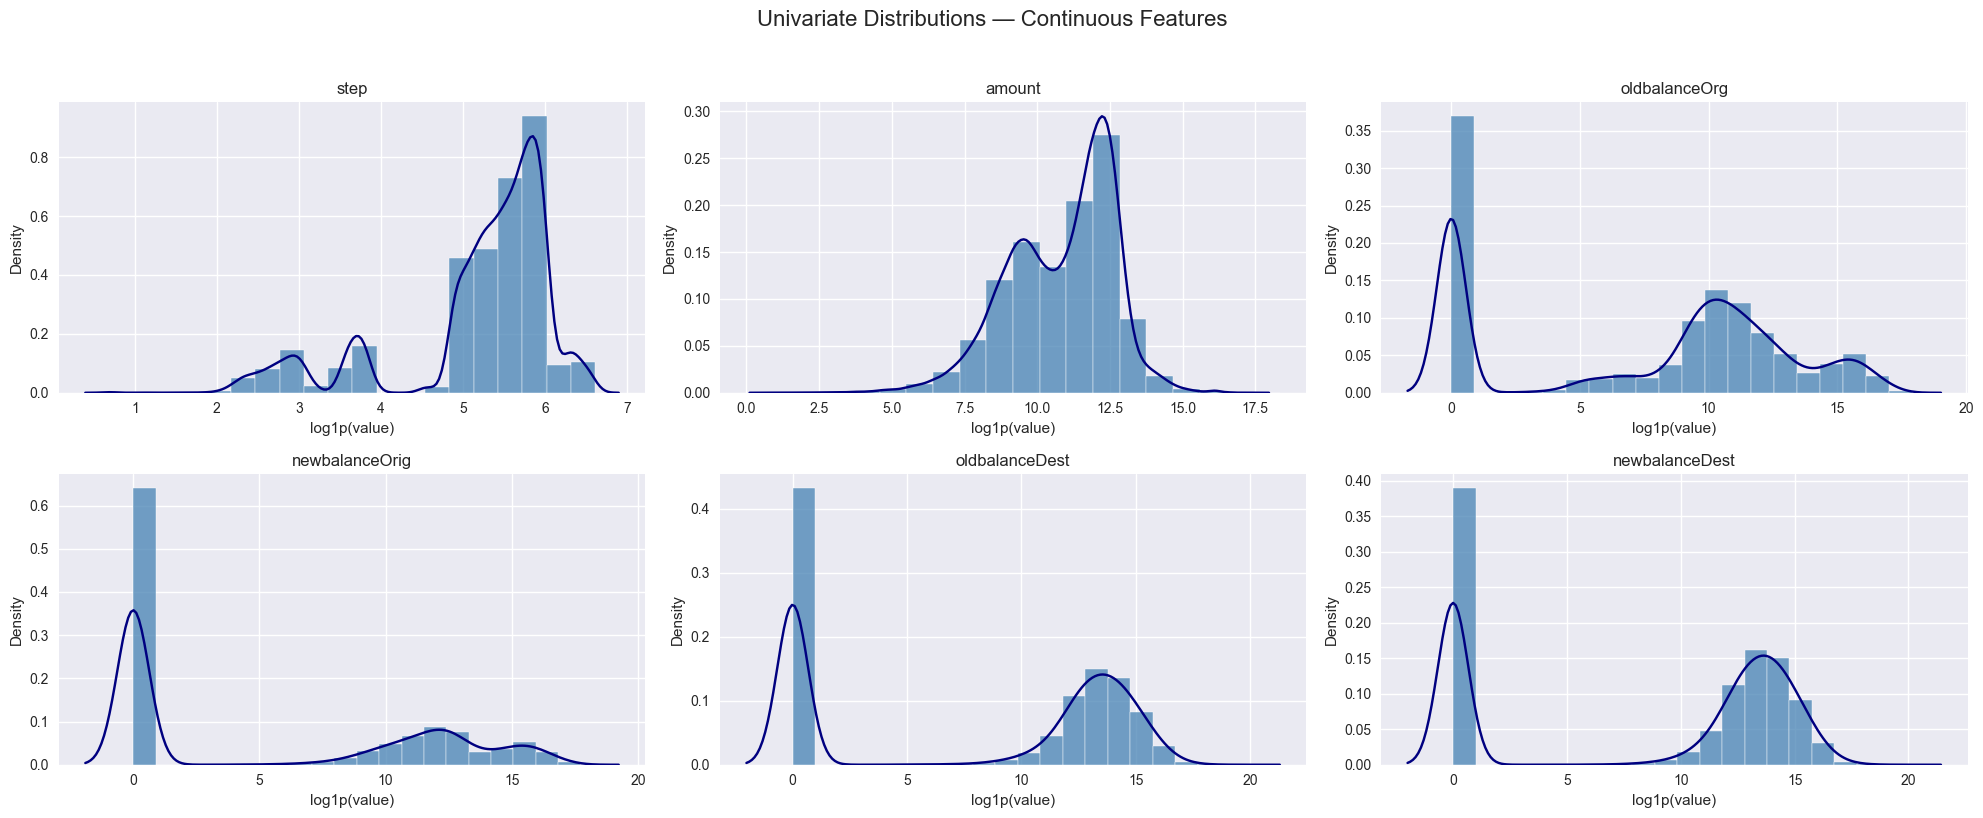

In [ ]:
continuous_features = ['step', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest']

fig, axes = plt.subplots(2, 3, figsize=(20, 8))
axes = axes.flatten()

for i, feature in enumerate(continuous_features):
    sns.histplot(np.log1p(df[feature]), bins=20, kde=False, ax=axes[i], color='steelblue', edgecolor='white', stat='density')
    sns.kdeplot(np.log1p(df[feature].sample(n=100_000, random_state=RANDOM_STATE)), ax=axes[i], color='navy') # so kde is done on sample of 100k for efficiency 
    axes[i].set_title(feature)
    axes[i].set_xlabel('log1p(value)')
    axes[i].set_ylabel('Density')

fig.suptitle('Univariate Distributions — Continuous Features', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig('../images/continuous_distributions.png', bbox_inches='tight')
plt.show()



Across the balance features, applying the `log1p` transformation caused the zero values to collapse into a sharp spike near zero, while the non-zero balances spread into their own right-skewed shape. On the log scale this can look like a bimodal distribution, but it's actually a single zero-inflated distribution (a point-mass at zero plus a right-skewed spread of non-zero balances) not a true bimodal shape in the original dollar scale. 

- `step` and `amount`: Zero-inflation does not apply to these two features, which makes sense since it would be very odd for a transaction `amount` to be 0. `step` has its highest peak desity at ~6 and `amount` has a somewhat steady increase in density going from ~5.0 to peak at 12.5. The peak transaction density around a particular `step` value suggest that either transactions cluster around a certain time period which could be meaningful in identifying when fraud likely happens, or it could also just be an artifact of how the simulation was constructed based on real world transaction data.

- `oldbalanceOrig` and `newbalanceOrig`: The zero-mass exists for `oldbalanceOrig`, `newbalanceOrig`. Additionally, `oldbalanceOrig` and `newbalanceOrig` have different density of 0s, `oldbalanceOrig` density of ~0.37 and `newbalanceOrig` density of ~0.65. This density shift between old (~0.37) and new (~0.65) means that some transactions are draining previously non-zero accounts down to 0. The origin balances hitting 0 is consistent with the account being drained, the transaction type(s) that drive this will be checked in the chain/cross analysis. 

- `oldbalanceDest`, and `newbalanceDest`: The zero-mass exists for `oldbalanceDest`, and `newbalanceDest`, which makes sense since accounts that are newly created or transferred all their money would be 0 which is more expected. `oldbalanceDest` and `newbalanceDest`, appear to have very similar graphs, but `newbalanceDest` has slightly fewer 0s (Density ~0.39) than `oldbalanceDest` (Density ~0.44). This shift between new (~0.39) and old (~0.44) suggests some destination accounts that started with a balance of 0 ended up non-zero after the transaction, which is consistent with accounts being credited (receiving money) for the first time.

The zero-inflation/skew of these continuous features will be revisited in feature engineering, since skew matters differently for different models. 

### Categorical Features
`type`, `isFlaggedFraud`, `nameOrig`, `nameDest`

In [6]:
if pd.api.types.is_integer_dtype(df['isFlaggedFraud']): # prevents accidently rerunning the mapping, which would set all values to null. 
    df['isFlaggedFraud'] = df['isFlaggedFraud'].map({0: 'No', 1: 'Yes'})

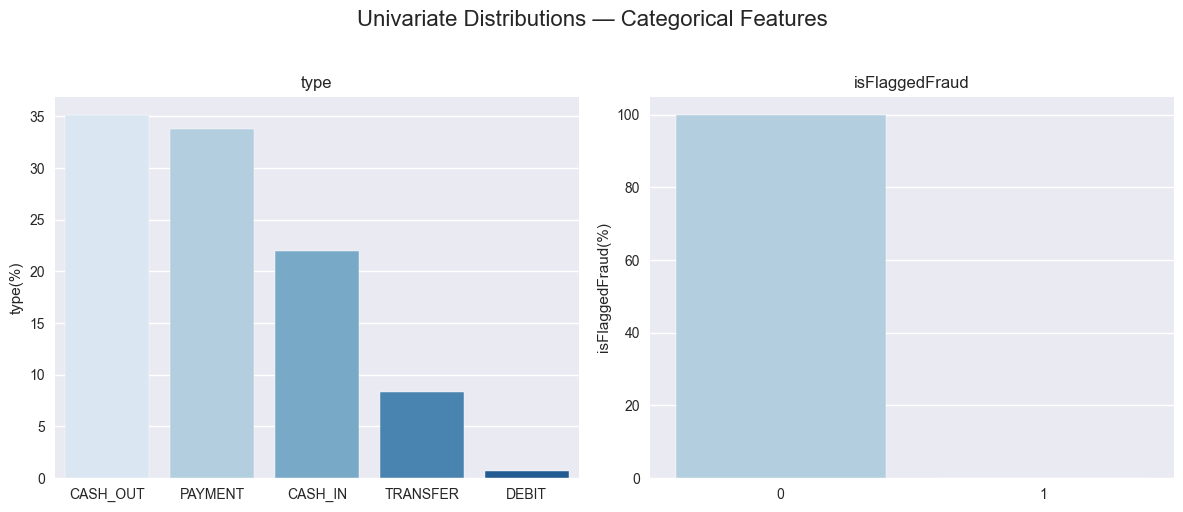

In [10]:
categorical_features = ['type', 'isFlaggedFraud']

fig, axes = plt.subplots(1, 2 , figsize=(12, 5))
axes = axes.flatten()

for i, feature in enumerate(categorical_features):
    feature_rates = df[feature].value_counts(normalize=True) 
    sns.barplot(x=feature_rates.index, y=feature_rates.values*100, ax=axes[i], palette='Blues')
    axes[i].set_title(feature)
    axes[i].set_xlabel('')
    axes[i].set_ylabel(f'{feature}(%)')

fig.suptitle('Univariate Distributions — Categorical Features', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig('../images/categorical_distributions.png', bbox_inches='tight')
plt.show()

- `type`: the order of % of type from highest to lowest is: `CASH_OUT`(~35) > `PAYMENT`(~34) > `CASH_IN`(~22) > `TRANSFER`(~8) > `Debit`(~1). Seeing how `TRANSFER` makes up only about 8% of all transactions and has the highest fraud rate (~0.77%), `Type` will likely be the strongest signal for detecting fraud for our model. However, because fraud is concentrated in `TRANSFER`, which is both a low-volume transaction type and has a low fraud rate, this creates a severe class imbalance. This imbalance will make modeling harder since a naive model could achieve high accuracy while missing nearly all fraud cases. This issue will need to be addressed through techniques like resampling, class weighting, or threshold tuning rather than relying on accuracy as the evaluation metric.

- `isFlaggedFraud`: 100% of `isFlaggedFraud` are `No`, meaning it has no variance and can't help any model distinguish anything. Therefore, I will drop it from the feature set for modeling. However, the fraud-flagging mechanism never flagging, even on the fraud cases that exist in the dataset suggests that the dataset (or the simulated rules behind it) could be broken, too conservative, or just decorative. This could be a limitation for our model even though it won't be a feature included in modeling. 

In [ ]:
print(df['nameOrig'].value_counts().head(10))
df['nameDest'].value_counts().head(10)

nameOrig
C2098525306    3
C400299098     3
C1999539787    3
C1065307291    3
C545315117     3
C1976208114    3
C1784010646    3
C1530544995    3
C1902386530    3
C1677795071    3
Name: count, dtype: int64


nameDest
C1286084959    113
C985934102     109
C665576141     105
C2083562754    102
C248609774     101
C1590550415    101
C451111351      99
C1789550256     99
C1360767589     98
C1023714065     97
Name: count, dtype: int64

`nameOrig` accounts appear at most 3 times, while `nameDest` accounts appear up to 113 times. This confirms that `nameorig` behaves like a mostly unique account identifier, while subsets of `nameDest` accounts repeatedly receive funds. This is consistent with some destination accounts acting as recurring recipients rather than one-off counterparties — normal individual customers usually don't receive money from dozens of transactions, but a merchant, exchange, or mule/cash-out account would naturally receive funds repeatedly. Whether these high frequency destination accounts overlap specifically with the `TRANSFER`-> `CASH_OUT` fraud pattern from Q2 is not yet established. This will be tested in the chain analysis section which requires directly joining `nameDest` in `TRANSFER` rows against `nameOrig` in `CASH_OUT` rows. 

## 1.6 Bivariate Analysis

For bivariate analysis of continuous features I first use a violin plot to visualize the distribution between the continuous features and the target `isFraud`. Violin plot was the best choice over boxplot because univariate analysis showed that the features have unusual shapes like zero-inflation so I don't care about central tendency or outliers. log1p is applied on all features because of the heavy right-skew — `step` isn't skewed but the logp1 doesnt affect readability of visualization so its applied for consistancy. 

I will also compare the continuous features with respect to the different categories of `type`

Lastly, I will use a crosstab/heatmap to analyize the fraud rate of `type` x `isFraud`, since these visualization methods will make the visual actually readable and not an extremely small `isFraud=1` like in target distribution. 

The other categorical variables are identifiers and will be analysize in chain analysis 

### Continuous Features

I split the dataset by `isFraud`, keeping all ~8,000 fraud rows (since they're rare and every one is valuable) and sampling the much larger `isFraud=0` group down to 100,000 rows, then used `pd.concat()` to combine them into one dataframe for plotting. This keeps the plot functioning efficiently while preserving the full fraud signal.

In [4]:
fraud_rows = df[df['isFraud'] == 1]
nfraud_rows = df[df['isFraud'] == 0].sample(n=100_000, random_state=RANDOM_STATE)
df_sampled = pd.concat([fraud_rows, nfraud_rows])

In [8]:
if pd.api.types.is_integer_dtype(df_sampled['isFraud']): # prevents accidently rerunning the mapping, which would set all values to null. 
    df_sampled['isFraud'] = df_sampled['isFraud'].map({0: 'No', 1: 'Yes'})
    

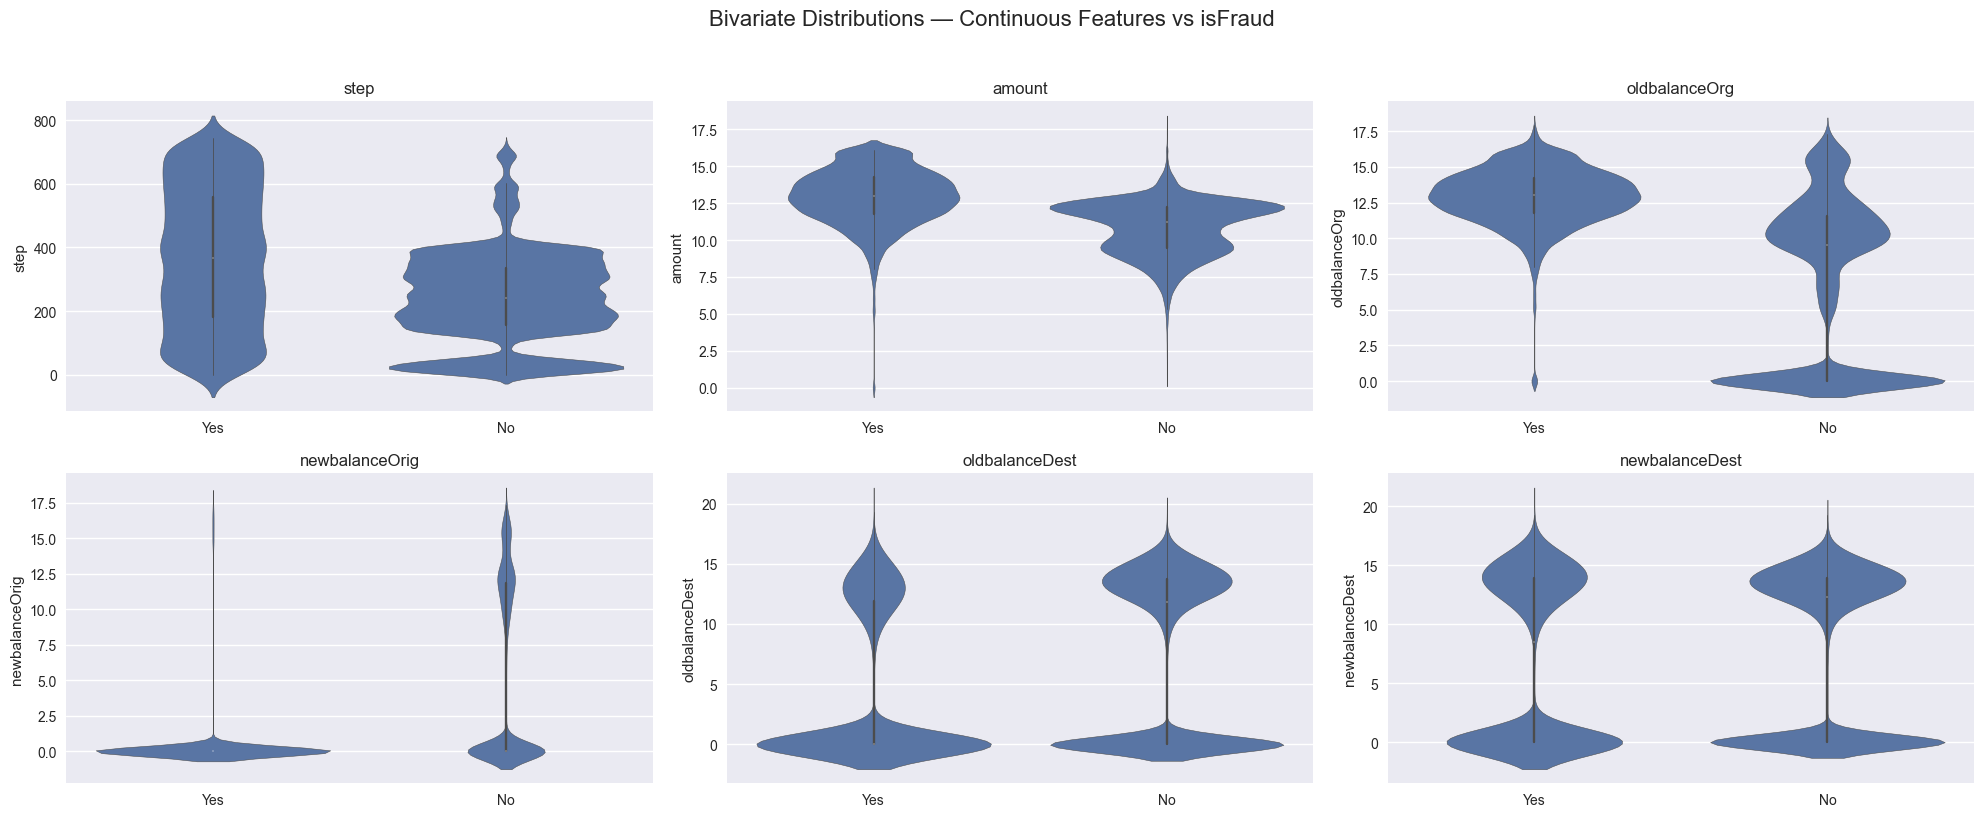

In [11]:
continuous_features = ['step', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest']

fig, axes = plt.subplots(2, 3, figsize=(20, 8))
axes = axes.flatten()

for i, feature in enumerate(continuous_features):
    if feature == 'step':
        sns.violinplot(x='isFraud', y=feature, data=df_sampled, ax=axes[i])
    else:
        sns.violinplot(x='isFraud', y=np.log1p(df_sampled[feature]), data=df_sampled, ax=axes[i])
    axes[i].set_title(feature)
    axes[i].set_xlabel('')
    axes[i].set_ylabel(feature)

fig.suptitle('Bivariate Distributions — Continuous Features vs isFraud', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig('../images/bivariate_continuous.png', bbox_inches='tight')
plt.show()

`oldbalanceOrig`: `isFraud = No` has a very wide distribution at 0.0 but also widens at 10.0. `isFraud = Yes` has a very skinny distribution untul 7.5 and then a wide distribution from 10.0 to 17.5. This means most likely fraud specifically targest accounts that have money which makes sense since there would be nothing to take from an empty account.

`newbalanceOrig`: `isFraud = No` has a slight bubble bellow 2.5 but is realatively skinny for the other values. `isFraud = Yes` has a wide flat distribution at 2.5 but then is extremely skinny for the remaing values. 

`oldbalanceDest`: `isFraud = No` and `isFraud = Yes` have visually very similar distributions with `isFraud = No` having a slightly wider distribution between 10 to 15, and a slightly flatter distribution at 0.0 than `isFraud = Yes`. this makes sese since `isFraud = No` has a lot of 0s.

`newbalanceDest`: `isFraud = No` and `isFraud = Yes` have very similar distributions with `isFraud = No` having slightly wider distribution near 15 and flater but wider distribution at 0.0. this makes sese since `isFraud = No` has a lot of 0s.

`amount`: `isFraud = Yes` sits slightlyhigher for its distribution than `isFraud = No` with `isFraud = No` having a less round shape than `isFraud = Yes`. This suggest that in this dataset fraud operates on large-value transfers instead of small rountine payments. 

`step`: `isFraud = Yes` is concentrated higher steps while `isFraud = No` is more spread and has its widest distributions around 6 and bellow whereas `isFraud = Yes` has its widest distribution above 6 and has a very steady expansion from 1 to 7. This supports the hypothesis that fraud timing matters. 

seeing how there is little different in distribution for old and new balanceDest, those will be weak predictors and the other 4 will be stronger since there is larger differences in their distributions. 

### Categorical Features